# Retail Sales Data Analysis

## Project Overview
This project analyzes a retail sales dataset containing 1,000 transactions to identify sales trends, customer behavior, and product performance.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### Objectives
- Analyze sales performance by product category
- Identify monthly sales trends
- Compare customer spending by gender
- Analyze sales across different age groups
- Calculate key business metrics

# 1. Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load and Explore the Dataset

In [43]:
df = pd.read_csv("retail_sales_dataset.csv")

In [44]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [45]:
df.shape

(1000, 9)

In [46]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


# 3. Data Cleaning

In [48]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df["Date"] = pd.to_datetime(df["Date"])

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [52]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


# 4. Product Category Analysis

In [53]:
df["Product Category"].unique()

array(['Beauty', 'Clothing', 'Electronics'], dtype=object)

In [54]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [55]:
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [56]:
 df.groupby("Product Category")["Total Amount"].mean().sort_values(ascending=False)

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

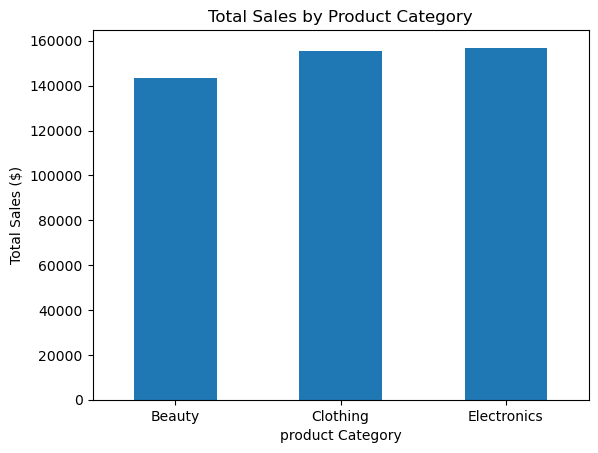

In [57]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("product Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

# Insights:
Electronics genertaed the highest total sales revenue, while clothing had the highest number of transactions.Beauty had the lowest total revenue but the highest average transaction value.

# 5. Monthly Sales Ananlysis

In [58]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

In [59]:
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

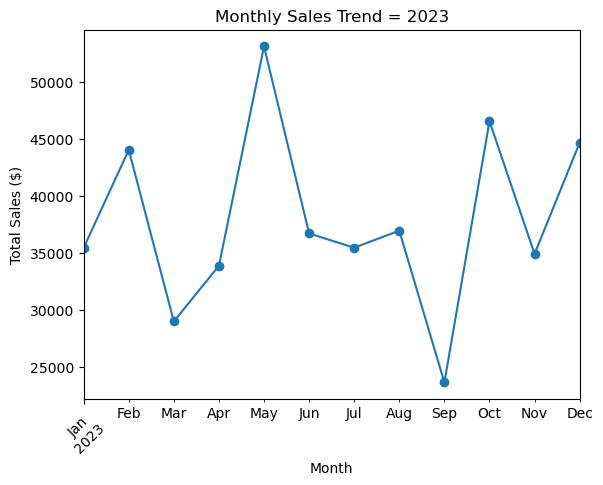

In [60]:
df_2023 = df[df["Date"].dt.year == 2023]

monthly_sales_2023 = df_2023.groupby(
    df_2023["Date"].dt.to_period("M")
)["Total Amount"].sum()

monthly_sales_2023.plot(kind = "line", marker="o")

plt.title("Monthly Sales Trend = 2023")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.show()

# Insight
Sales fluctuated throughout 2023. May recorded the highest monthly sales, while september recorded the lowest. Sales increased again toward the end of the year, especially in october and december.

# 6. Customer Gender Amalysis

In [61]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [62]:
df.groupby("Gender")["Total Amount"].sum()

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

# Insight
Female customers accounted for slightly more transactions and generated slightly higher total revenue than male customers, although sales were relatively balanced between bith groups.

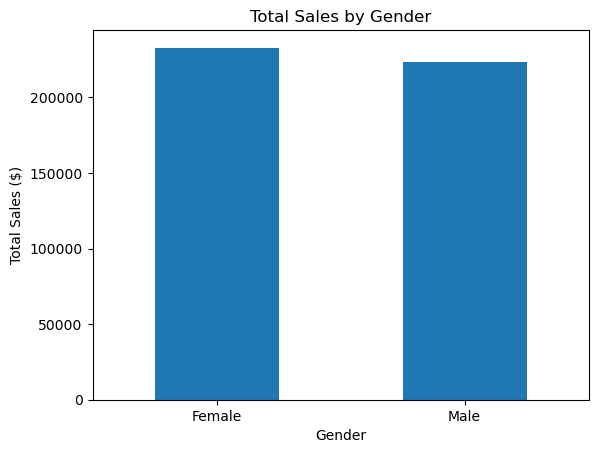

In [63]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

# Insight
Female customers genertaed slightly higher total sales than male customers, but overall spending was fairly balanced between the two groups

# 7. Age Group Analysis

In [64]:
bins = [17,25,35,45,55,65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)    

In [65]:
df.groupby("Age Group", observed=True)["Total Amount"].sum().sort_values(ascending=False)

Age Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56-65     80410
Name: Total Amount, dtype: int64

# Insight
Customers aged 46-55 generated the highest total sales revenue, followed by the 26-35 age group. Customers aged 56-65 genertaed the lowest total sales.

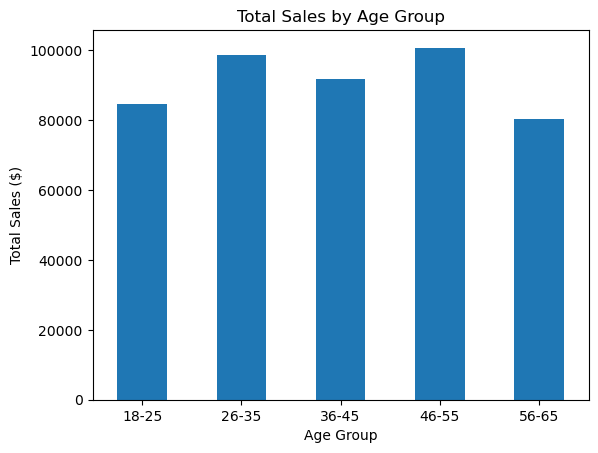

In [66]:
age_sales = df.groupby("Age Group", observed=True)["Total Amount"].sum()

age_sales.plot(kind="bar")

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

# 8. Key Business Metrics

In [67]:
total_revenue = df["Total Amount"].sum()
total_items = df["Quantity"].sum()
avg_transaction = df["Total Amount"].mean()

print("Total Revenue: $", total_revenue)
print("Total Items Sold:",total_items)
print("Average Transaction: $", avg_transaction)

Total Revenue: $ 456000
Total Items Sold: 2514
Average Transaction: $ 456.0


# Conclusion
The retail dataset contained 1,000 transactions. Electronics generated the highest total revenue, while Clothing recorded the most transactions. Beauty had the highest average transaction value. May was the strongest sales month in 2023, while September was the weakest. Female and male customer spending was relatively balanced, Customers aged 46-55 generated the highest sales among the age groups.